#### Model

- Given the high prevalence of missing values and the likely non-linear relationships between features and the target, a boosting-based approach is well suited for this problem. I chose XGBoost due to its strong track record in handling imbalanced classification tasks and its flexibility in capturing complex, non-linear patterns.

- A common alternative in credit risk modeling is Logistic Regression; however, in its standard form it assumes linear decision boundaries. Given the observed feature behavior, this assumption is likely too restrictive for this dataset (though not formally tested here).

- The model is optimized using `log_loss`, while hyperparameter tuning is guided by `PR-AUC`, which is more appropriate for highly imbalanced datasets.

- This approach provides several advantages:
  - ability to model non-linear relationships  
  - native handling of missing values without requiring imputation  
  - robustness to multicollinearity among features  

- Model performance on the test set is moderate. In the context of risk scoring, correctly identifying positive cases (defaults) is typically more critical than minimizing false positives. Therefore, Recall is considered more important than Precision in this setting.

#### Load Data

In [ ]:

import pickle
import joblib
import json
import shap 
import pandas as pd
import numpy as np
import warnings

import random
import category_encoders as ce
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from sklearn.metrics import roc_auc_score, recall_score, precision_score, average_precision_score, confusion_matrix
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from preprocessing import QuantileBinner
from utils import evaluate_and_report

import category_encoders as ce
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 1000)
pd.options.display.float_format = '{:.5f}'.format

df = pd.read_csv("./dataset.csv", sep = ";")
df['has_paid'] = df['has_paid'].astype(int)

df_nna = df[df['default'].notna()]  # observations for which we have default values (Training + Validation set)
#df_na = df[df['default'].isna()]    # observations for which we dont have default values (Unlabeled data)

X = df_nna.drop(columns=["default"])
y = df_nna["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)


#### Model 1: XgBoost
- WoE Encoding for categorical and numerical values with NaNs 

In [ ]:



# IDENTIFY COLUMNS

na_columns = X_train.columns[X_train.isna().any()].tolist()

numeric_columns = X_train.select_dtypes(include=np.number).columns.tolist()
cat_columns = [col for col in X_train.columns if col not in numeric_columns]

num_na_columns = [col for col in na_columns if col in numeric_columns]
num_no_na_columns = [col for col in numeric_columns if col not in num_na_columns]


# PIPELINES

# numeric with NA → bin + WoE
num_na_pipeline = Pipeline([
    ("binning", QuantileBinner(n_bins=10)),
    ("woe", ce.WOEEncoder(handle_unknown='value', handle_missing='value'))
])

# numeric without NA → passthrough
num_pipeline = Pipeline([
    ("passthrough", "passthrough")
])

# categorical → WoE (NA handled internally)
cat_pipeline = Pipeline([
    ("encoder", ce.WOEEncoder(handle_unknown='value', handle_missing='value'))
])

preprocessor = ColumnTransformer([
    ("num_na_woe", num_na_pipeline, num_na_columns),
    ("num", num_pipeline, num_no_na_columns),
    ("cat_woe", cat_pipeline, cat_columns),
])

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = Pipeline([
    ("preprocessing", preprocessor),
    ("clf", XGBClassifier(
        eval_metric="auc",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        use_label_encoder=False
    ))
])


param_dist = {
    "clf__n_estimators": [200,300,500,1000],
    "clf__max_depth": [3, 5, 8],
    "clf__learning_rate": [0.01, 0.02, 0.05, 0.1],
    "clf__subsample": [0.7, 0.8, 0.9, 1.0],
    "clf__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "clf__gamma": np.linspace(0, 2, 5),
    "clf__min_child_weight": [1, 3, 5, 10],
    "clf__reg_lambda": np.linspace(0, 3, 5),
    "clf__reg_alpha": np.linspace(0, 3, 5),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    #scoring="roc_auc",
    scoring="average_precision",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# MODEL TRAINING
random_search.fit(X_train, y_train)

evaluate_and_report(random_search, X_test, y_test)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END clf__colsample_bytree=0.8, clf__gamma=1.0, clf__learning_rate=0.05, clf__max_depth=5, clf__min_child_weight=10, clf__n_estimators=200, clf__reg_alpha=2.25, clf__reg_lambda=0.75, clf__subsample=1.0; total time=  16.9s
[CV] END clf__colsample_bytree=0.8, clf__gamma=1.0, clf__learning_rate=0.05, clf__max_depth=5, clf__min_child_weight=10, clf__n_estimators=200, clf__reg_alpha=2.25, clf__reg_lambda=0.75, clf__subsample=1.0; total time=  17.1s
[CV] END clf__colsample_bytree=0.8, clf__gamma=1.0, clf__learning_rate=0.05, clf__max_depth=5, clf__min_child_weight=10, clf__n_estimators=200, clf__reg_alpha=2.25, clf__reg_lambda=0.75, clf__subsample=1.0; total time=  17.1s
[CV] END clf__colsample_bytree=0.8, clf__gamma=1.0, clf__learning_rate=0.05, clf__max_depth=5, clf__min_child_weight=10, clf__n_estimators=200, clf__reg_alpha=2.25, clf__reg_lambda=0.75, clf__subsample=1.0; total time=  17.4s
[CV] END clf__colsample_bytree=0.8,

#### Serialize the model

In [ ]:
best_model = random_search.best_estimator_
joblib.dump({
    "model": best_model,
    "features": X_train.columns.tolist()
}, "model_bundle.pkl")

['model_bundle.pkl']

#### Load and run the model

In [32]:

bundle = joblib.load('./model_bundle.pkl')

mod = bundle["model"]
features = bundle["features"]

temp = pd.read_json("loan5.json")
temp = temp.reindex(columns=features)
temp["pd"] = mod.predict_proba(temp)[:, 1]

print(temp[["uuid", "pd"]])

                                   uuid      pd
0  e9bb70db-4cf7-42f4-ae58-c843d260fd6b 0.00236
1  9e33e4ba-16b4-4fad-8925-3295d57462a7 0.00035
2  0714405e-0328-43f9-9be2-63df4c79b4c2 0.74446
3  25163c16-968b-4aa0-89ea-8b9a301f763a 0.20637
4  bfcadf5a-55fd-456a-83d1-13470bb41755 0.08675


#### Feature Importance with Shap

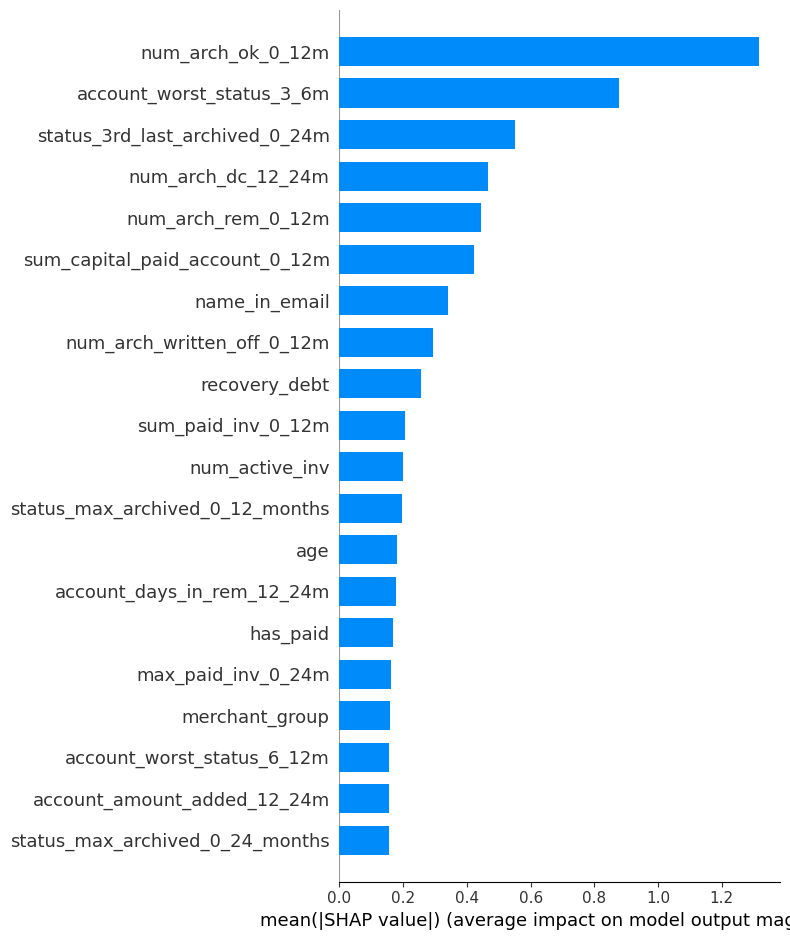

In [ ]:
xgb_model = mod.named_steps["clf"]
X_transformed = mod.named_steps["preprocessing"].transform(temp)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_transformed)
shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=features,
    plot_type="bar"
)